## Recursive Least Squares with Statsmodels: copper dataset

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [3]:
print(sm.datasets.copper.DESCRLONG)

This data describes the world copper market from 1951 through 1975.  In an
example, in Gill, the outcome variable (of a 2 stage estimation) is the world
consumption of copper for the 25 years.  The explanatory variables are the
world consumption of copper in 1000 metric tons, the constant dollar adjusted
price of copper, the price of a substitute, aluminum, an index of real per
capita income base 1970, an annual measure of manufacturer inventory change,
and a time trend.



In [4]:
data = sm.datasets.copper.load_pandas().data

In [5]:
data.head()

,WORLDCONSUMPTION,COPPERPRICE,INCOMEINDEX,ALUMPRICE,INVENTORYINDEX,TIME
0,3173.0,26.56,0.70,19.76,0.98,1.0
1,3281.1,27.31,0.71,20.78,1.04,2.0
2,3135.7,32.95,0.72,22.55,1.05,3.0
3,3359.1,33.90,0.70,23.06,0.97,4.0
4,3755.1,42.70,0.74,24.93,1.02,5.0


In [9]:
data.columns

Index(['WORLDCONSUMPTION', 'COPPERPRICE', 'INCOMEINDEX', 'ALUMPRICE',
       'INVENTORYINDEX', 'TIME'],
      dtype='object')

In [10]:
data.index = pd.date_range("1951-01-01", "1975-01-01", freq="YS")
endog = data['WORLDCONSUMPTION']
exog = sm.add_constant(data[['COPPERPRICE', 'INCOMEINDEX', 'ALUMPRICE', 'INVENTORYINDEX', 'TIME']])

In [14]:
model = sm.RecursiveLS(endog, exog)
res = model.fit()
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Statespace Model Results                           
==============================================================================
Dep. Variable:       WORLDCONSUMPTION   No. Observations:                   25
Model:                    RecursiveLS   Log Likelihood                -145.915
Date:                Thu, 16 Jul 2026   R-squared:                       0.978
Time:                        17:22:13   AIC                            303.830
Sample:                    01-01-1951   BIC                            311.144
                         - 01-01-1975   HQIC                           305.859
Covariance Type:            nonrobust   Scale                        76536.817
==================================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const            283.9552   2768.572      0.103      0.918   -5142.347    5710.257
COPPERPRICE       15.0432     14.761      1.019      0.308     -13.888      43.974
INCOMEINDEX     1442.8858   3168.592      0.455      0.649   -4767.441    7653.213
ALUMPRICE        -64.1230     47.258     -1.357      0.175    -156.747      28.501
INVENTORYINDEX  2450.3845   1827.270      1.341      0.180   -1130.999    6031.768
TIME             187.2307     54.595      3.429      0.001      80.226     294.236
===================================================================================
Ljung-Box (L1) (Q):                   0.49   Jarque-Bera (JB):                10.29
Prob(Q):                              0.48   Prob(JB):                         0.01
Heteroskedasticity (H):               6.00   Skew:                            -1.38
Prob(H) (two-sided):                  0.05   Kurtosis:                         5.32
===================================================================================

Warnings:
[1] Parameters and covariance matrix estimates are RLS estimates conditional on the entire sample.
"""

In [15]:
res.recursive_coefficients.filtered[0]

array([ 2.88627302e+00,  3.25961107e+00,  2.81797170e+01,  1.06096418e+03,
        1.19162853e+04,  9.25186768e+04, -6.57472097e+02, -1.08915642e+03,
       -2.95268399e+02, -6.87158264e+02, -3.74568114e+02,  1.46861955e+02,
        8.59723280e+02, -1.24197641e+03, -1.02982261e+03, -6.07717294e+01,
        1.40660605e+03,  1.93738425e+03,  2.22102917e+03,  2.45627493e+03,
        2.20760789e+03,  2.53919001e+03,  3.37818744e+03,  2.77743232e+03,
        2.83955186e+02])

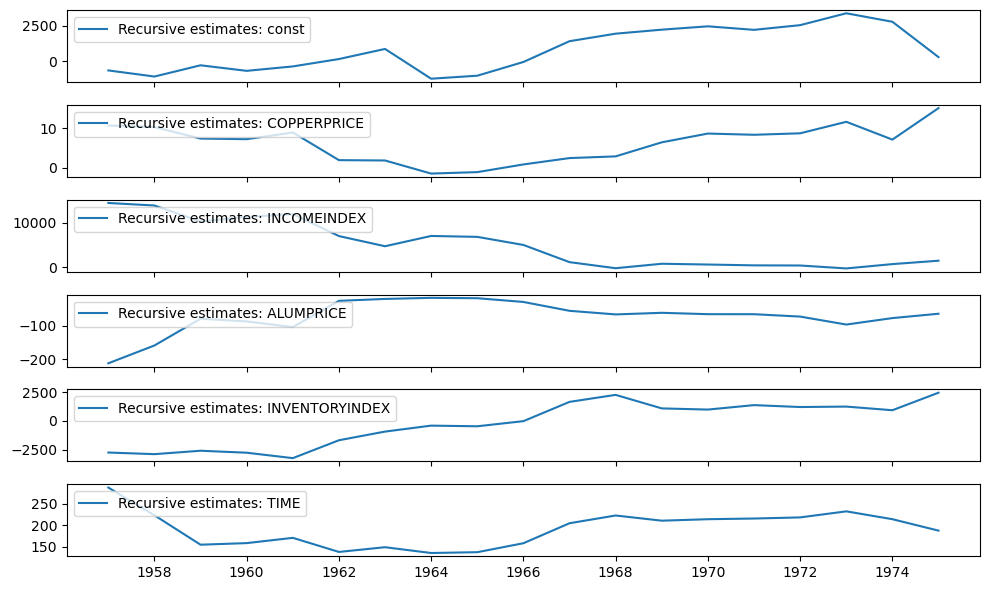

In [17]:
res.plot_recursive_coefficient(range(model.k_exog), alpha=None, figsize=(10,6));

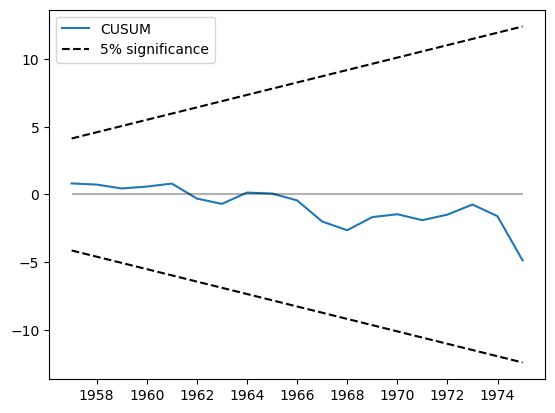

In [20]:
res.plot_cusum();

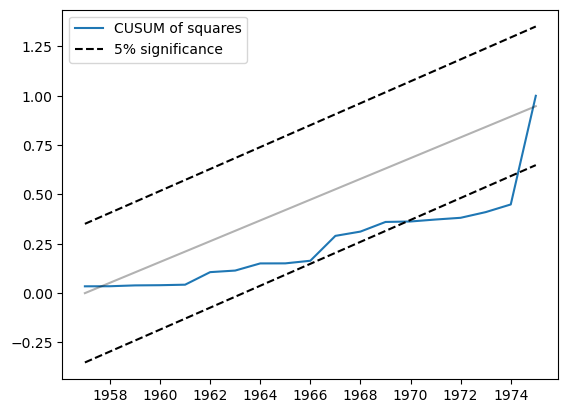

In [21]:
res.plot_cusum_squares();